In [1]:
# CHANGE: plt.style.use('ggplot') → try 'bmh', 'classic', 'ggplot'
# CHANGE: ALPHA = 0.05 → change to 0.01 for stricter testing
# CHANGE: C1, C2, C3 hex codes → changes all chart colours at once

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from scipy.stats import shapiro, levene, ttest_1samp, ttest_ind, ttest_rel
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'figure.dpi': 120, 'savefig.bbox': 'tight'})

C1    = '#2196F3'   # Blue   → One-Sample
C2    = '#4CAF50'   # Green  → Two-Sample Group 2
C3    = '#FF5722'   # Orange → Paired
ALPHA = 0.05

print("✅ Ready")

✅ Ready


In [2]:
# CHANGE: filenames below if your files have different names or are in a subfolder

FILE_SLEEP  = 'student_stress_sleep_screen.csv'
FILE_SCORES = 'student-mat.csv'
FILE_BP     = 'Health_Sleep_Statistics.csv'

for label, f in [("FILE 1", FILE_SLEEP),
                 ("FILE 2", FILE_SCORES),
                 ("FILE 3", FILE_BP)]:
    df = pd.read_csv(f)
    print(f"\n{'='*55}\n{label}: {f}")
    print("Shape  :", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(3).to_string())


FILE 1: student_stress_sleep_screen.csv
Shape  : (500, 10)
Columns: ['student_id', 'age', 'gender', 'sleep_hours', 'screen_time_hours', 'stress_level', 'study_hours', 'physical_activity', 'caffeine_intake', 'academic_pressure']
  student_id  age  gender  sleep_hours  screen_time_hours stress_level  study_hours physical_activity  caffeine_intake academic_pressure
0       S001   22  Female          5.9                2.7       Medium          7.4               Yes                3              High
1       S002   25    Male          5.9                7.6         High          4.6                No                2               Low
2       S003   23    Male          8.0                3.2          Low          2.0               Yes                3              High

FILE 2: student-mat.csv
Shape  : (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsu

In [3]:
# CHANGE: MU_0 → hypothesised population mean for One-Sample test
# CHANGE: .head(150) → use more or fewer rows
# CHANGE: 'school' == 'GP' / 'MS' → swap for any other category column

# ── One-Sample ────────────────────────────────────────────────────────────────
df1        = pd.read_csv(FILE_SLEEP)[['student_id','sleep_hours']].dropna().head(150)
sleep_data = df1['sleep_hours'].values
MU_0       = 8.0

# ── Two-Sample ────────────────────────────────────────────────────────────────
df2      = pd.read_csv(FILE_SCORES)[['school','G3']].dropna()
group_GP = df2[df2['school'] == 'GP']['G3'].values
group_MS = df2[df2['school'] == 'MS']['G3'].values

# ── Paired ────────────────────────────────────────────────────────────────────
df3         = pd.read_csv(FILE_BP)[['User ID','Daily Steps','Calories Burned']].dropna()
paired_A    = df3['Daily Steps'].values    / 1000   # scaled to same unit
paired_B    = df3['Calories Burned'].values / 1000
paired_diff = paired_A - paired_B

print(f"One-Sample  : n={len(sleep_data)}, mean={sleep_data.mean():.2f}")
print(f"Two-Sample  : GP n={len(group_GP)} mean={group_GP.mean():.2f} | MS n={len(group_MS)} mean={group_MS.mean():.2f}")
print(f"Paired      : n={len(paired_diff)}, mean diff={paired_diff.mean():.2f}")

One-Sample  : n=150, mean=6.67
Two-Sample  : GP n=349 mean=10.49 | MS n=46 mean=9.85
Paired      : n=100, mean diff=4.41


In [4]:
# Nothing to change here — reads values already computed in Cell 3

summary = pd.DataFrame({
    'Test'      : ['One-Sample', 'Two-Sample', 'Paired'],
    'File'      : [FILE_SLEEP, FILE_SCORES, FILE_BP],
    'Column(s)' : ['sleep_hours', 'G3 by school', 'Daily Steps vs Calories'],
    'n'         : [len(sleep_data),
                   f'GP={len(group_GP)}, MS={len(group_MS)}',
                   len(paired_diff)],
    'Question'  : ['Sleep = 8h?', 'GP ≠ MS grades?', 'Steps ≠ Calories?']
})
print(summary.to_string(index=False))

      Test                            File               Column(s)             n          Question
One-Sample student_stress_sleep_screen.csv             sleep_hours           150       Sleep = 8h?
Two-Sample                 student-mat.csv            G3 by school GP=349, MS=46   GP ≠ MS grades?
    Paired     Health_Sleep_Statistics.csv Daily Steps vs Calories           100 Steps ≠ Calories?


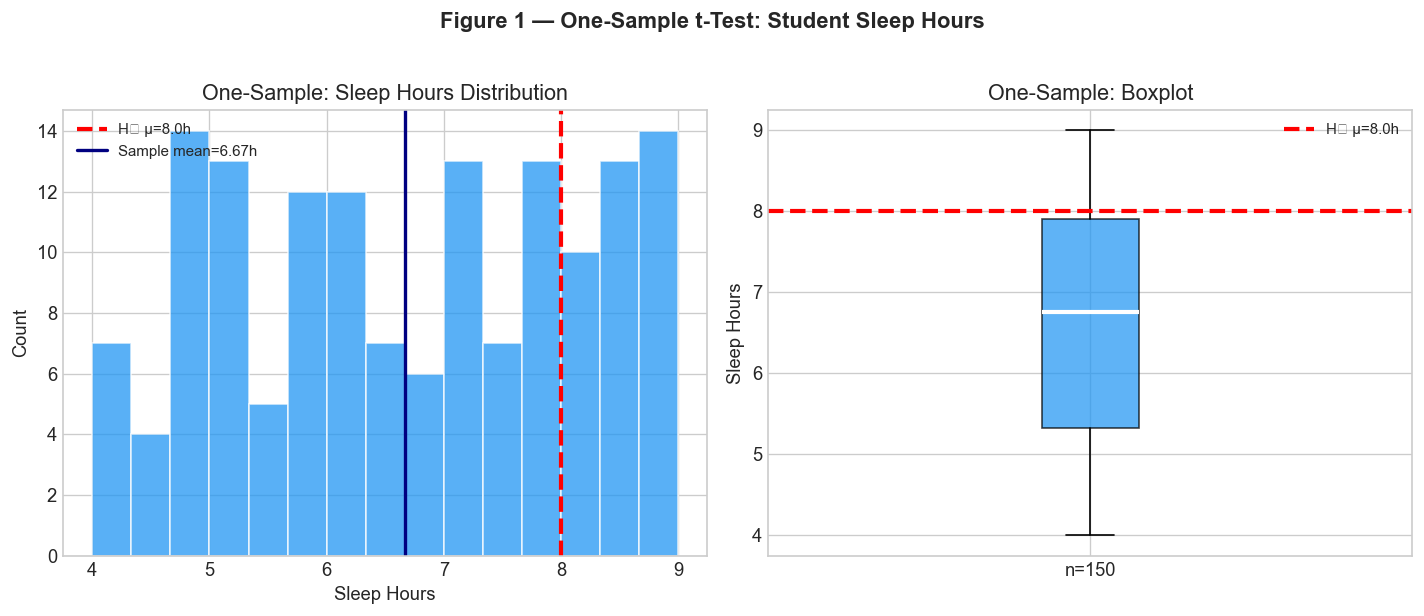

In [5]:
# CELL 5: One-Sample visualisation — Histogram + Boxplot
# CHANGE: bins=15      → more bins = finer bars, fewer = wider bars
# CHANGE: MU_0        → moves the red reference line left or right
# CHANGE: C1          → changes bar and box colour

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax1.hist(sleep_data, bins=15, color=C1, alpha=0.75, edgecolor='white')
ax1.axvline(MU_0, color='red', lw=2.5, ls='--', label=f'H₀ μ={MU_0}h')
ax1.axvline(sleep_data.mean(), color='navy', lw=2, ls='-',
            label=f'Sample mean={sleep_data.mean():.2f}h')
ax1.set_xlabel('Sleep Hours'); ax1.set_ylabel('Count')
ax1.set_title('One-Sample: Sleep Hours Distribution')
ax1.legend(fontsize=9)

# Boxplot
ax2.boxplot(sleep_data, patch_artist=True,
            boxprops=dict(facecolor=C1, alpha=0.72),
            medianprops=dict(color='white', lw=2.5))
ax2.axhline(MU_0, color='red', lw=2.5, ls='--', label=f'H₀ μ={MU_0}h')
ax2.set_xticklabels([f'n={len(sleep_data)}'])
ax2.set_ylabel('Sleep Hours'); ax2.set_title('One-Sample: Boxplot')
ax2.legend(fontsize=9)

plt.suptitle('Figure 1 — One-Sample t-Test: Student Sleep Hours', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_onesample.png')
plt.show()

In [6]:
# CHANGE: MU_0 in Cell 3 → changes the null hypothesis value
# CHANGE: ALPHA in Cell 1 → changes the rejection threshold

t1, p1  = ttest_1samp(sleep_data, MU_0)
n1      = len(sleep_data)
m1      = sleep_data.mean()
se1     = sleep_data.std(ddof=1) / np.sqrt(n1)
df1_val = n1 - 1
ci1     = (m1 + stats.t.ppf(0.025, df1_val)*se1,
           m1 + stats.t.ppf(0.975, df1_val)*se1)
sw1, sp1 = shapiro(sleep_data)
dec1    = 'Reject H₀' if p1 < ALPHA else 'Fail to Reject H₀'

print(f"  H₀            : μ = {MU_0}")
print(f"  n             : {n1}")
print(f"  Sample mean   : {m1:.4f}")
print(f"  t-statistic   : {t1:.4f}")
print(f"  df            : {df1_val}")
print(f"  p-value       : {p1:.6f}")
print(f"  95% CI        : [{ci1[0]:.4f}, {ci1[1]:.4f}]")
print(f"  Shapiro-Wilk  : W={sw1:.4f}, p={sp1:.4f}")
print(f"  Decision (α={ALPHA}): {dec1}")
print(f"\n  Students slept {m1:.2f}h on average. t({df1_val})={t1:.3f}, p={p1:.4f}. {dec1}.")

  H₀            : μ = 8.0
  n             : 150
  Sample mean   : 6.6660
  t-statistic   : -11.1826
  df            : 149
  p-value       : 0.000000
  95% CI        : [6.4303, 6.9017]
  Shapiro-Wilk  : W=0.9414, p=0.0000
  Decision (α=0.05): Reject H₀

  Students slept 6.67h on average. t(149)=-11.183, p=0.0000. Reject H₀.


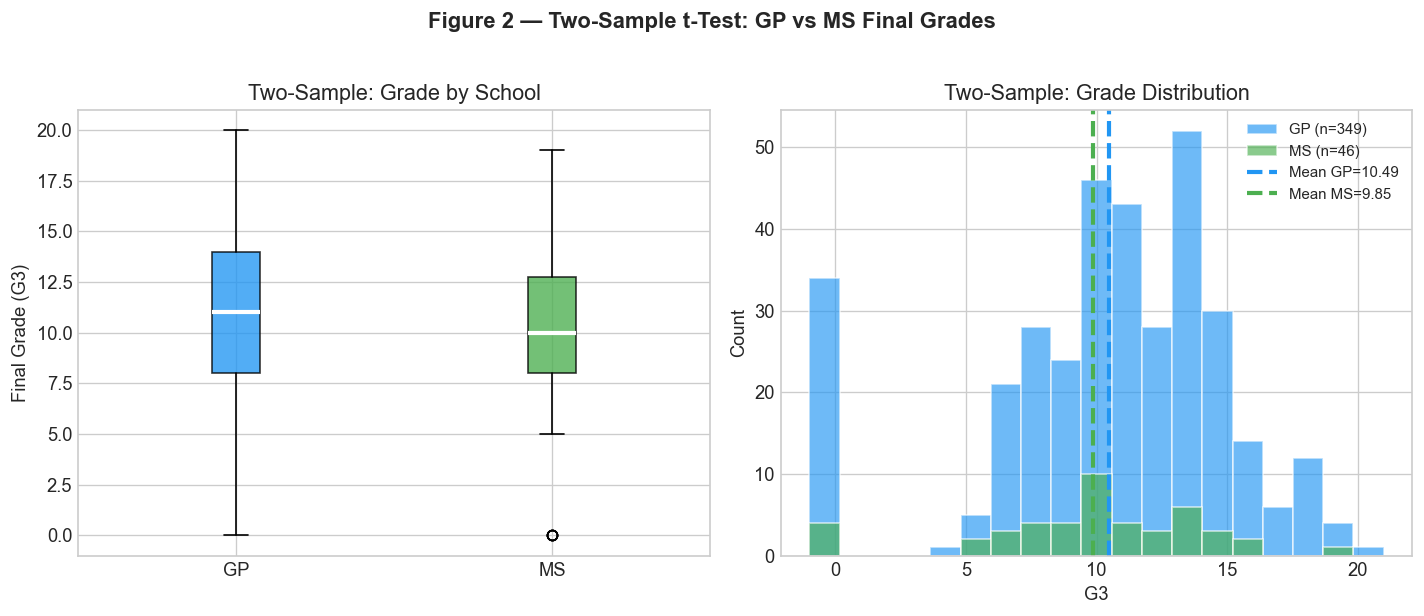

In [7]:
# CHANGE: bins count (20) → more = finer, fewer = broader
# CHANGE: C1 / C2 → colours for GP and MS groups
# CHANGE: alpha=0.65 → lower = more transparent bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Boxplots
bp = ax1.boxplot([group_GP, group_MS], patch_artist=True,
                 labels=['GP', 'MS'],
                 medianprops=dict(color='white', lw=2.5))
for patch, c in zip(bp['boxes'], [C1, C2]):
    patch.set(facecolor=c, alpha=0.78)
ax1.set_ylabel('Final Grade (G3)'); ax1.set_title('Two-Sample: Grade by School')

# Histograms
bins = np.linspace(min(group_GP.min(), group_MS.min())-1,
                   max(group_GP.max(), group_MS.max())+1, 20)
ax2.hist(group_GP, bins=bins, alpha=0.65, color=C1, edgecolor='white',
         label=f'GP (n={len(group_GP)})')
ax2.hist(group_MS, bins=bins, alpha=0.65, color=C2, edgecolor='white',
         label=f'MS (n={len(group_MS)})')
ax2.axvline(group_GP.mean(), color=C1, lw=2.5, ls='--',
            label=f'Mean GP={group_GP.mean():.2f}')
ax2.axvline(group_MS.mean(), color=C2, lw=2.5, ls='--',
            label=f'Mean MS={group_MS.mean():.2f}')
ax2.set_xlabel('G3'); ax2.set_ylabel('Count')
ax2.set_title('Two-Sample: Grade Distribution'); ax2.legend(fontsize=9)

plt.suptitle('Figure 2 — Two-Sample t-Test: GP vs MS Final Grades',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_twosample.png')
plt.show()

In [8]:
# CHANGE: equal_var=False → True to use classic Student's t (only if Levene passes)
# CHANGE: ALPHA in Cell 1 → changes rejection threshold

t2, p2   = ttest_ind(group_GP, group_MS, equal_var=False)
nGP, nMS = len(group_GP), len(group_MS)
mGP, mMS = group_GP.mean(), group_MS.mean()
vGP, vMS = group_GP.var(ddof=1), group_MS.var(ddof=1)
se2      = np.sqrt(vGP/nGP + vMS/nMS)
df2_val  = (vGP/nGP + vMS/nMS)**2 / ((vGP/nGP)**2/(nGP-1) + (vMS/nMS)**2/(nMS-1))
ci2      = (mGP - mMS + stats.t.ppf(0.025, df2_val)*se2,
            mGP - mMS + stats.t.ppf(0.975, df2_val)*se2)
sw_gp, sp_gp = shapiro(group_GP[:50])
sw_ms, sp_ms = shapiro(group_MS)
lf2, lp2     = levene(group_GP, group_MS)
dec2         = 'Reject H₀' if p2 < ALPHA else 'Fail to Reject H₀'

print(f"  H₀            : μ_GP = μ_MS")
print(f"  n_GP / n_MS   : {nGP} / {nMS}")
print(f"  Means         : GP={mGP:.4f}, MS={mMS:.4f}")
print(f"  t-statistic   : {t2:.4f}")
print(f"  df (Welch)    : {df2_val:.2f}")
print(f"  p-value       : {p2:.6f}")
print(f"  95% CI (diff) : [{ci2[0]:.4f}, {ci2[1]:.4f}]")
print(f"  Shapiro GP    : W={sw_gp:.4f}, p={sp_gp:.4f}")
print(f"  Shapiro MS    : W={sw_ms:.4f}, p={sp_ms:.4f}")
print(f"  Levene        : F={lf2:.4f}, p={lp2:.4f}")
print(f"  Decision (α={ALPHA}): {dec2}")
print(f"\n  GP mean={mGP:.2f}, MS mean={mMS:.2f}. t({df2_val:.1f})={t2:.3f}, p={p2:.4f}. {dec2}.")

  H₀            : μ_GP = μ_MS
  n_GP / n_MS   : 349 / 46
  Means         : GP=10.4900, MS=9.8478
  t-statistic   : 0.9555
  df (Welch)    : 60.05
  p-value       : 0.343132
  95% CI (diff) : [-0.7021, 1.9864]
  Shapiro GP    : W=0.9688, p=0.2076
  Shapiro MS    : W=0.9318, p=0.0098
  Levene        : F=0.8377, p=0.3606
  Decision (α=0.05): Fail to Reject H₀

  GP mean=10.49, MS mean=9.85. t(60.1)=0.956, p=0.3431. Fail to Reject H₀.


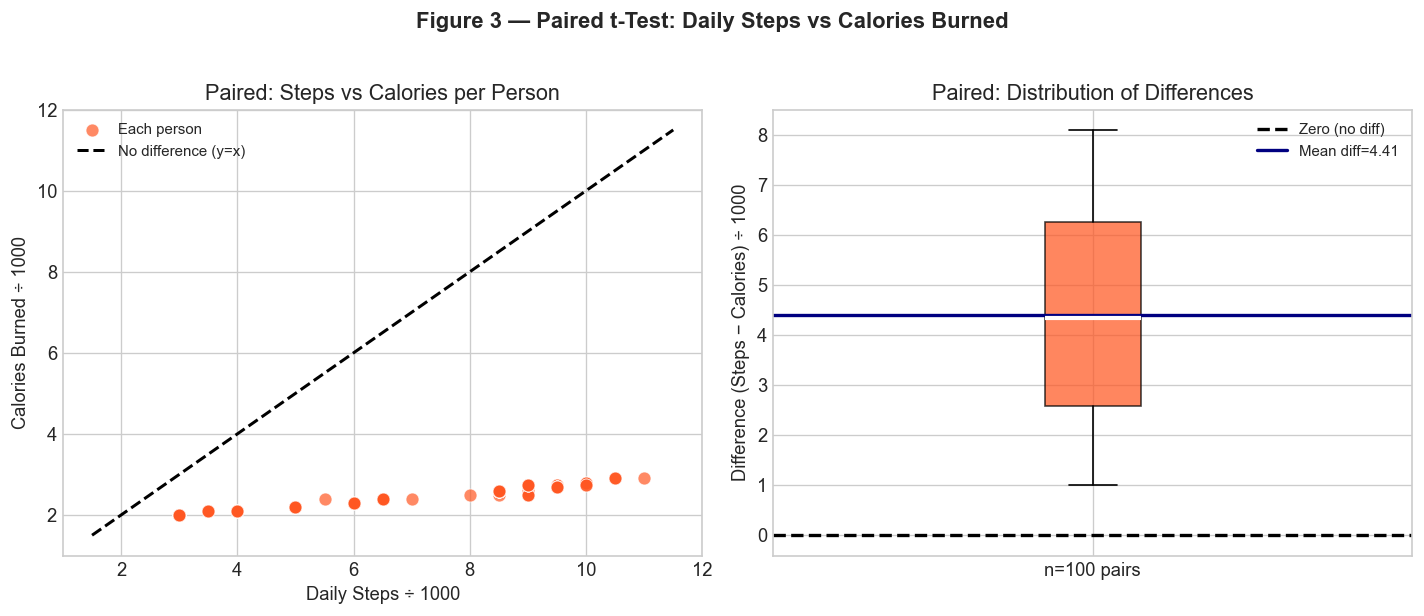

In [9]:
# CHANGE: s=60 → dot size in scatter plot
# CHANGE: C3  → colour of dots and box
# CHANGE: alpha=0.7 → transparency of scatter dots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter
ax1.scatter(paired_A, paired_B, color=C3, alpha=0.7, s=60,
            edgecolors='white', lw=0.5, label='Each person')
lo = min(paired_A.min(), paired_B.min()) - 0.5
hi = max(paired_A.max(), paired_B.max()) + 0.5
ax1.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='No difference (y=x)')
ax1.set_xlabel('Daily Steps ÷ 1000'); ax1.set_ylabel('Calories Burned ÷ 1000')
ax1.set_title('Paired: Steps vs Calories per Person'); ax1.legend(fontsize=9)

# Difference Boxplot
ax2.boxplot(paired_diff, patch_artist=True,
            boxprops=dict(facecolor=C3, alpha=0.72),
            medianprops=dict(color='white', lw=2.5))
ax2.axhline(0, color='black', lw=2, ls='--', label='Zero (no diff)')
ax2.axhline(paired_diff.mean(), color='navy', lw=2,
            label=f'Mean diff={paired_diff.mean():.2f}')
ax2.set_xticklabels([f'n={len(paired_diff)} pairs'])
ax2.set_ylabel('Difference (Steps − Calories) ÷ 1000')
ax2.set_title('Paired: Distribution of Differences'); ax2.legend(fontsize=9)

plt.suptitle('Figure 3 — Paired t-Test: Daily Steps vs Calories Burned',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_paired.png')
plt.show()

In [10]:
# CHANGE: ALPHA in Cell 1 → changes rejection threshold
# NOTE: normality is checked on the DIFFERENCES, not raw values

t3, p3   = ttest_rel(paired_A, paired_B)
n3       = len(paired_diff)
md3      = paired_diff.mean()
se3      = paired_diff.std(ddof=1) / np.sqrt(n3)
df3_val  = n3 - 1
ci3      = (md3 + stats.t.ppf(0.025, df3_val)*se3,
            md3 + stats.t.ppf(0.975, df3_val)*se3)
sw3, sp3 = shapiro(paired_diff)
dec3     = 'Reject H₀' if p3 < ALPHA else 'Fail to Reject H₀'

print(f"  H₀            : μ_d = 0")
print(f"  n (pairs)     : {n3}")
print(f"  Mean diff     : {md3:.4f}")
print(f"  t-statistic   : {t3:.4f}")
print(f"  df            : {df3_val}")
print(f"  p-value       : {p3:.6f}")
print(f"  95% CI        : [{ci3[0]:.4f}, {ci3[1]:.4f}]")
print(f"  Shapiro-Wilk  : W={sw3:.4f}, p={sp3:.4f}  (on differences)")
print(f"  Decision (α={ALPHA}): {dec3}")
print(f"\n  Mean diff={md3:.2f}. t({df3_val})={t3:.3f}, p={p3:.4f}. {dec3}.")

  H₀            : μ_d = 0
  n (pairs)     : 100
  Mean diff     : 4.4090
  t-statistic   : 19.8440
  df            : 99
  p-value       : 0.000000
  95% CI        : [3.9681, 4.8499]
  Shapiro-Wilk  : W=0.8966, p=0.0000  (on differences)
  Decision (α=0.05): Reject H₀

  Mean diff=4.41. t(99)=19.844, p=0.0000. Reject H₀.


In [11]:
results = pd.DataFrame({
    'Test'        : ['One-Sample', 'Two-Sample (Welch)', 'Paired'],
    'H₀'          : [f'μ={MU_0}h', 'μ_GP=μ_MS', 'μ_d=0'],
    't'           : [round(t1,3), round(t2,3), round(t3,3)],
    'df'          : [df1_val, round(df2_val,1), df3_val],
    'p-value'     : [round(p1,4), round(p2,4), round(p3,4)],
    '95% CI'      : [f'[{ci1[0]:.2f}, {ci1[1]:.2f}]',
                     f'[{ci2[0]:.2f}, {ci2[1]:.2f}]',
                     f'[{ci3[0]:.2f}, {ci3[1]:.2f}]'],
    'Decision'    : [dec1, dec2, dec3]
})

print("=" * 75)
print("  FINAL SUMMARY — All Three t-Tests  |  α =", ALPHA)
print("=" * 75)
print(results.to_string(index=False))
print("=" * 75)
print("\nFigures saved: fig1_onesample.png | fig2_twosample.png | fig3_paired.png")

  FINAL SUMMARY — All Three t-Tests  |  α = 0.05
              Test        H₀       t    df  p-value        95% CI          Decision
        One-Sample    μ=8.0h -11.183 149.0   0.0000  [6.43, 6.90]         Reject H₀
Two-Sample (Welch) μ_GP=μ_MS   0.956  60.1   0.3431 [-0.70, 1.99] Fail to Reject H₀
            Paired     μ_d=0  19.844  99.0   0.0000  [3.97, 4.85]         Reject H₀

Figures saved: fig1_onesample.png | fig2_twosample.png | fig3_paired.png
